Detecting Bots via Mouse Movement Biometrics

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.model_selection import train_test_split

print('All imports successful.')

All imports successful.


In [17]:
BASE_PATH = r'C:\Users\jayd1\Downloads\nirmamtech\mldl\assgnmnt prjct\delbot-mouse' 

# Maximum sequence length (events per session)
# Sessions shorter than this are padded, longer ones are truncated
# 200 covers the 75th percentile of all session lengths
MAX_LEN = 200

# Random seed for reproducibility
SEED = 42

HUMAN_FOLDERS = [
    'circles_human_pc1',
    'circles_human_pc2',
    'circles_human_pc2_pad',
    'circles_human_vm',
]

BOT_FOLDERS = {
    'circles_bot_pynput':             'pynput',
    'circles_bot_pyhm':               'pyhm',
    'circles_bot_naturalmousemotion': 'naturalmousemotion',
    'circles_bot_gan':                'gan',
}

# Event type encoding
EVENT_MAP = {
    'Move': 0, 'Pressed': 1, 'Released': 2
}

print('Configuration set.')
print(f'Base path: {BASE_PATH}')
print(f'Max sequence length: {MAX_LEN}')

Configuration set.
Base path: C:\Users\jayd1\Downloads\nirmamtech\mldl\assgnmnt prjct\delbot-mouse
Max sequence length: 200


In [6]:
print(f'{'Folder':<45} {'Type':<8} {'Files'}\n' + '-'*65)

all_folders = HUMAN_FOLDERS + list(BOT_FOLDERS.keys())
total_human, total_bot = 0, 0

for folder in all_folders:
    path = os.path.join(BASE_PATH, folder)
    if not os.path.exists(path):
        print(f'WARNING: {folder} not found at {path}')
        continue
    count = len(os.listdir(path))
    ftype = 'HUMAN' if folder in HUMAN_FOLDERS else 'BOT'
    print(f'{folder:<45} {ftype:<8} {count}')
    if ftype == 'HUMAN': total_human += count
    else: total_bot += count

print('-'*65)
print(f'{'Total Human':<45} {'':8} {total_human}')
print(f'{'Total Bot':<45} {'':8} {total_bot}')
print(f'{'GRAND TOTAL':<45} {'':8} {total_human + total_bot}')

Folder                                        Type     Files
-----------------------------------------------------------------
circles_human_pc1                             HUMAN    187
circles_human_pc2                             HUMAN    459
circles_human_pc2_pad                         HUMAN    62
circles_human_vm                              HUMAN    140
circles_bot_pynput                            BOT      408
circles_bot_pyhm                              BOT      55
circles_bot_naturalmousemotion                BOT      234
circles_bot_gan                               BOT      1899
-----------------------------------------------------------------
Total Human                                            848
Total Bot                                              2596
GRAND TOTAL                                            3444


In [7]:
# Preview one human file and one bot file
sample_human = os.path.join(BASE_PATH, HUMAN_FOLDERS[0],
                            os.listdir(os.path.join(BASE_PATH, HUMAN_FOLDERS[0]))[0])
sample_bot   = os.path.join(BASE_PATH, 'circles_bot_pynput',
                            os.listdir(os.path.join(BASE_PATH, 'circles_bot_pynput'))[0])

print('=== HUMAN SESSION (first 8 lines) ===')
with open(sample_human) as f:
    for i, line in enumerate(f):
        if i >= 9: break
        print(line.strip())

print('\n=== BOT SESSION (pynput, first 8 lines) ===')
with open(sample_bot) as f:
    for i, line in enumerate(f):
        if i >= 9: break
        print(line.strip())

=== HUMAN SESSION (first 8 lines) ===
resolution:1920,1080
2583.10000000149,Pressed,964,208
2670.900000002235,Move,961,208
2678.900000002235,Move,958,208
2694.699999999255,Move,940,208
2718.900000002235,Move,902,208
2735,Move,867,211
2751,Move,845,219
2766.699999999255,Move,832,227

=== BOT SESSION (pynput, first 8 lines) ===
resolution:1536,864
4033.800000000745,Pressed,699,352
4049.5,Move,716,356
4100.5,Move,716,356
4116.099999997765,Move,716,356
4199.39999999851,Move,734,356
4316.199999999255,Move,751,349
4416.800000000745,Move,763,338
4500,Move,770,324


In [8]:
def parse_session(fpath):
    """
    Parse a single session .txt file.
    Returns a list of [timestamp, event_type, x_norm, y_norm] events.
    Coordinates are normalised by screen resolution.
    Returns None if the file is malformed.
    """
    with open(fpath, 'r', errors='ignore') as f:
        lines = f.readlines()

    if not lines:
        return None

    # Parse resolution from first line
    try:
        res_line = lines[0].strip()
        w, h = map(float, res_line.replace('resolution:', '').split(','))
    except:
        return None

    events = []
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',')
        if len(parts) != 4:
            continue
        try:
            ts     = float(parts[0])
            etype  = EVENT_MAP.get(parts[1].strip(), 0)
            x_norm = float(parts[2]) / w    # normalise x by screen width
            y_norm = float(parts[3]) / h    # normalise y by screen height
            events.append([ts, etype, x_norm, y_norm])
        except:
            continue

    return events if len(events) >= 10 else None


def normalise_timestamps(events):
    """
    Normalise timestamps to the range [0, 1].
    Subtract the first timestamp (so sessions start at 0),
    then divide by the total session duration.
    """
    t0 = events[0][0]
    for e in events:
        e[0] = e[0] - t0
    tmax = events[-1][0]
    if tmax > 0:
        for e in events:
            e[0] = e[0] / tmax
    return events


def pad_or_truncate(events, max_len):
    """
    Make all sessions the same length.
    Truncate sessions longer than max_len.
    Pad shorter sessions with zero rows at the end.
    """
    if len(events) >= max_len:
        return events[:max_len]
    pad_row = [0.0, 0, 0.0, 0.0]
    return events + [pad_row] * (max_len - len(events))


print('Helper functions defined.')

Helper functions defined.


In [9]:
# Load all sessions
sessions, labels, bot_types = [], [], []
skipped = 0

# Human sessions
for folder in HUMAN_FOLDERS:
    path = os.path.join(BASE_PATH, folder)
    for fname in os.listdir(path):
        events = parse_session(os.path.join(path, fname))
        if events is None:
            skipped += 1
            continue
        events = normalise_timestamps(events)
        events = pad_or_truncate(events, MAX_LEN)
        sessions.append(events)
        labels.append(0)        # 0 = Human
        bot_types.append('human')

# Bot sessions
for folder, btype in BOT_FOLDERS.items():
    path = os.path.join(BASE_PATH, folder)
    for fname in os.listdir(path):
        events = parse_session(os.path.join(path, fname))
        if events is None:
            skipped += 1
            continue
        events = normalise_timestamps(events)
        events = pad_or_truncate(events, MAX_LEN)
        sessions.append(events)
        labels.append(1)        # 1 = Bot
        bot_types.append(btype)

# Convert to numpy arrays
X = np.array(sessions,  dtype=np.float32)
y = np.array(labels,    dtype=np.int32)
bot_types = np.array(bot_types)

print(f'Loading complete.')
print(f'Skipped (malformed): {skipped}')
print(f'\nX shape: {X.shape}  →  (sessions × timesteps × features)')
print(f'Features: [timestamp, event_type, x_normalised, y_normalised]')
print(f'\nHuman sessions: {(y==0).sum()}')
print(f'Bot sessions:   {(y==1).sum()}')
print(f'Total:          {len(y)}')

Loading complete.
Skipped (malformed): 0

X shape: (3444, 200, 4)  →  (sessions × timesteps × features)
Features: [timestamp, event_type, x_normalised, y_normalised]

Human sessions: 848
Bot sessions:   2596
Total:          3444


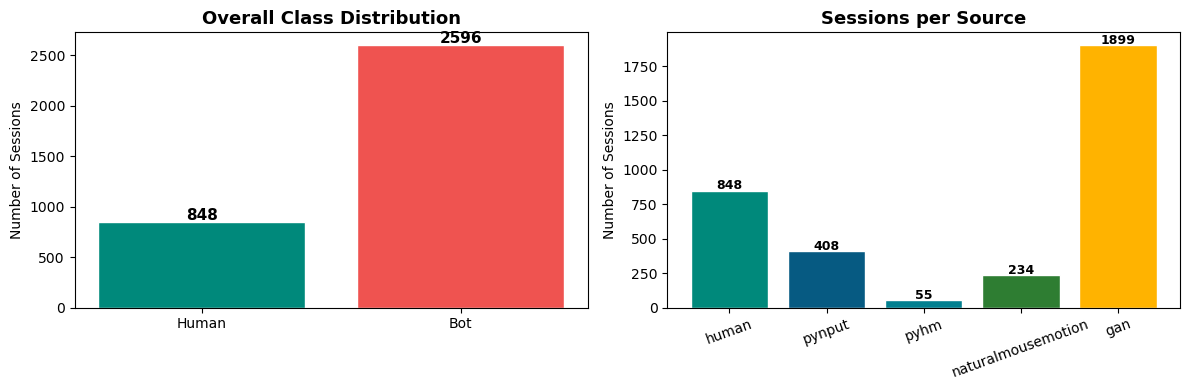

Note: Dataset is imbalanced — bots outnumber humans ~3:1. We will handle this during training.


In [10]:
# Plot 1 — Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall Human vs Bot
counts = [int((y==0).sum()), int((y==1).sum())]
axes[0].bar(['Human', 'Bot'], counts, color=['#00897B', '#EF5350'], edgecolor='white')
axes[0].set_title('Overall Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Sessions')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')

# Per bot type
type_counts = Counter(bot_types)
labels_bt = list(type_counts.keys())
values_bt = list(type_counts.values())
colors = ['#00897B','#065A82','#028090','#2E7D32','#FFB300','#EF5350','#6A1B9A','#558B2F']
axes[1].bar(labels_bt, values_bt, color=colors[:len(labels_bt)], edgecolor='white')
axes[1].set_title('Sessions per Source', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Sessions')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(values_bt):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Dataset is imbalanced — bots outnumber humans ~3:1. We will handle this during training.')

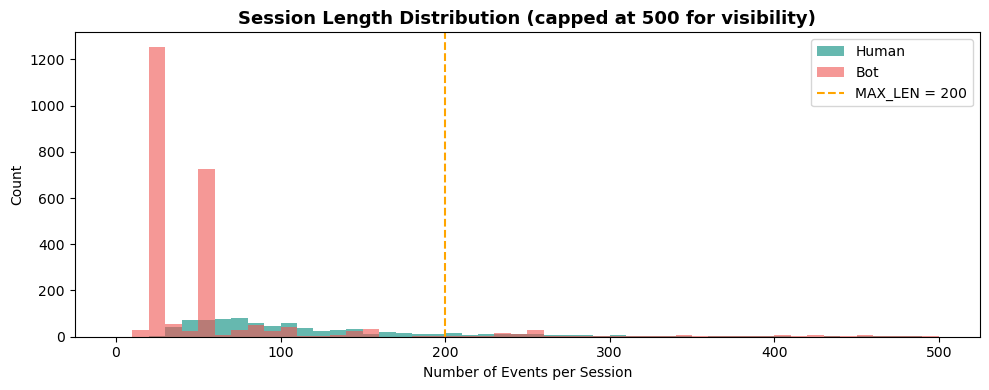

In [11]:
# Plot 2 — Session length distribution (before padding)
raw_lengths_human, raw_lengths_bot = [], []

for folder in HUMAN_FOLDERS:
    path = os.path.join(BASE_PATH, folder)
    for fname in os.listdir(path):
        events = parse_session(os.path.join(path, fname))
        if events: raw_lengths_human.append(len(events))

for folder in BOT_FOLDERS:
    path = os.path.join(BASE_PATH, folder)
    for fname in os.listdir(path):
        events = parse_session(os.path.join(path, fname))
        if events: raw_lengths_bot.append(len(events))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(raw_lengths_human, bins=50, alpha=0.6, color='#00897B', label='Human', range=(0, 500))
ax.hist(raw_lengths_bot,   bins=50, alpha=0.6, color='#EF5350', label='Bot',   range=(0, 500))
ax.axvline(MAX_LEN, color='orange', linestyle='--', linewidth=1.5, label=f'MAX_LEN = {MAX_LEN}')
ax.set_title('Session Length Distribution (capped at 500 for visibility)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Events per Session')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('session_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

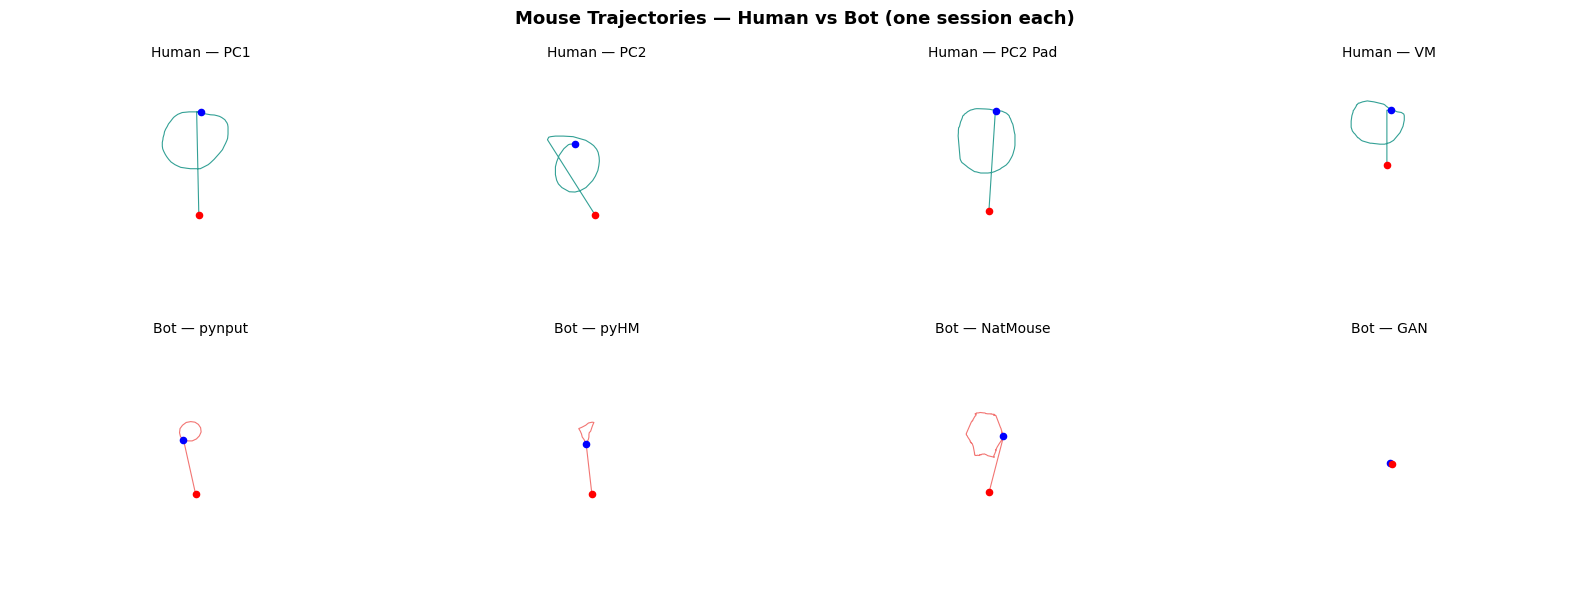

Observation: Human paths show natural curves and hesitations.
Bot paths (especially pynput) show more linear and repetitive movement.


In [12]:
# Plot 3 — Trajectory visualisation: Human vs Bot side by side
def get_trajectory(folder_path):
    fname = os.listdir(folder_path)[0]
    events = parse_session(os.path.join(folder_path, fname))
    if events is None: return [], []
    xs = [e[2] for e in events]  # already normalised
    ys = [e[3] for e in events]
    return xs, ys

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Mouse Trajectories — Human vs Bot (one session each)', fontsize=13, fontweight='bold')

# Top row: human sources
human_labels = ['PC1', 'PC2', 'PC2 Pad', 'VM']
for i, (folder, label) in enumerate(zip(HUMAN_FOLDERS, human_labels)):
    xs, ys = get_trajectory(os.path.join(BASE_PATH, folder))
    axes[0][i].plot(xs, ys, color='#00897B', linewidth=0.8, alpha=0.8)
    axes[0][i].scatter(xs[0], ys[0], color='blue', s=20, zorder=5, label='Start')
    axes[0][i].scatter(xs[-1], ys[-1], color='red', s=20, zorder=5, label='End')
    axes[0][i].set_title(f'Human — {label}', fontsize=10)
    axes[0][i].set_xlim(0, 1); axes[0][i].set_ylim(0, 1)
    axes[0][i].invert_yaxis()
    axes[0][i].axis('off')

# Bottom row: bot sources
bot_label_names = ['pynput', 'pyHM', 'NatMouse', 'GAN']
for i, (folder, label) in enumerate(zip(BOT_FOLDERS.keys(), bot_label_names)):
    xs, ys = get_trajectory(os.path.join(BASE_PATH, folder))
    axes[1][i].plot(xs, ys, color='#EF5350', linewidth=0.8, alpha=0.8)
    axes[1][i].scatter(xs[0], ys[0], color='blue', s=20, zorder=5)
    axes[1][i].scatter(xs[-1], ys[-1], color='red', s=20, zorder=5)
    axes[1][i].set_title(f'Bot — {label}', fontsize=10)
    axes[1][i].set_xlim(0, 1); axes[1][i].set_ylim(0, 1)
    axes[1][i].invert_yaxis()
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Human paths show natural curves and hesitations.')
print('Bot paths (especially pynput) show more linear and repetitive movement.')

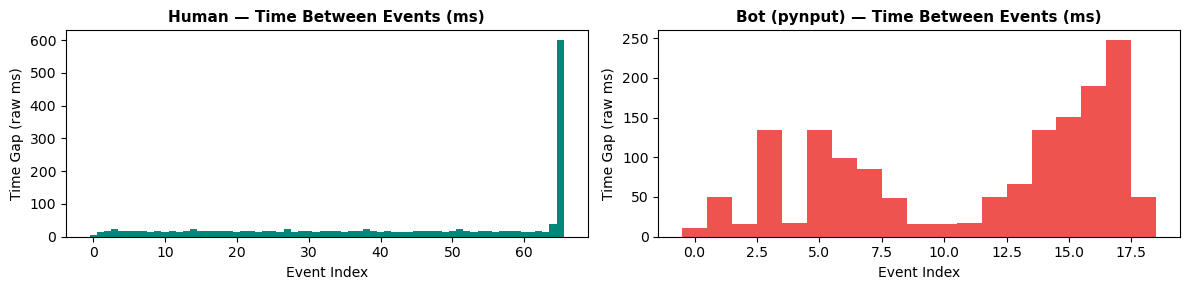

Observation: Human gaps are irregular and varied. Bot gaps are uniform — a clear distinguishing signal.


In [13]:
# Plot 4 — Timestamp spacing (inter-event time) for Human vs pynput bot
def get_time_gaps(folder_path):
    fname = os.listdir(folder_path)[3]  # pick 4th file for variety
    events = parse_session(os.path.join(folder_path, fname))
    if not events: return []
    gaps = [events[i][0] - events[i-1][0] for i in range(1, min(100, len(events)))]
    return gaps

human_gaps  = get_time_gaps(os.path.join(BASE_PATH, 'circles_human_pc1'))
pynput_gaps = get_time_gaps(os.path.join(BASE_PATH, 'circles_bot_pynput'))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(range(len(human_gaps)),  human_gaps,  color='#00897B', width=1.0)
axes[0].set_title('Human — Time Between Events (ms)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Event Index'); axes[0].set_ylabel('Time Gap (raw ms)')

axes[1].bar(range(len(pynput_gaps)), pynput_gaps, color='#EF5350', width=1.0)
axes[1].set_title('Bot (pynput) — Time Between Events (ms)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Event Index'); axes[1].set_ylabel('Time Gap (raw ms)')

plt.tight_layout()
plt.savefig('time_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Human gaps are irregular and varied. Bot gaps are uniform — a clear distinguishing signal.')

SPLITING INTO TRAINING, VALIDATION AND TEST

In [14]:
# Stratified split — keeps human/bot ratio the same in all three sets
# Split at session level — all events from one session stay together

# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

# Step 2: split temp equally into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print('Data split complete.')
print(f'\n{"Split":<15} {"Total":>8} {"Human":>8} {"Bot":>8}')
print('-' * 42)
for name, Xs, ys in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    print(f'{name:<15} {len(ys):>8} {int((ys==0).sum()):>8} {int((ys==1).sum()):>8}')
print('-' * 42)
print(f'{"Total":<15} {len(y):>8} {int((y==0).sum()):>8} {int((y==1).sum()):>8}')

Data split complete.

Split              Total    Human      Bot
------------------------------------------
Train               2410      593     1817
Validation           517      127      390
Test                 517      128      389
------------------------------------------
Total               3444      848     2596


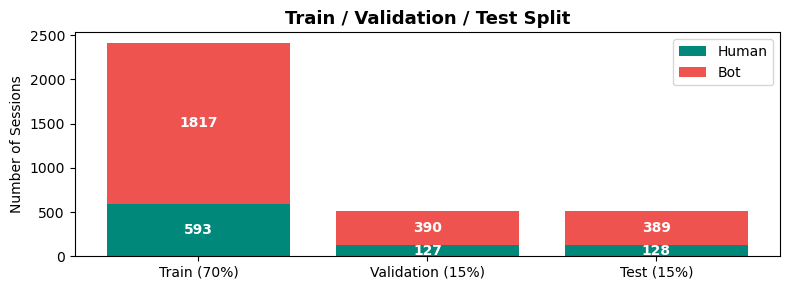

In [15]:
# Visualise the split proportions
fig, ax = plt.subplots(figsize=(8, 3))
splits  = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
totals  = [len(y_train), len(y_val), len(y_test)]
humans  = [(y_train==0).sum(), (y_val==0).sum(), (y_test==0).sum()]
bots    = [(y_train==1).sum(), (y_val==1).sum(), (y_test==1).sum()]

x = range(len(splits))
ax.bar(x, humans, color='#00897B', label='Human')
ax.bar(x, bots,   bottom=humans, color='#EF5350', label='Bot')
ax.set_xticks(list(x)); ax.set_xticklabels(splits)
ax.set_title('Train / Validation / Test Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Sessions')
ax.legend()
for i, (h, b) in enumerate(zip(humans, bots)):
    ax.text(i, h/2,   str(h), ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(i, h+b/2, str(b), ha='center', va='center', color='white', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('data_split.png', dpi=150, bbox_inches='tight')
plt.show()

Saving files just generated.

In [16]:
# Save all arrays as .npy files for use in the next notebook
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

print('Saved:')
for name in ['X_train','X_val','X_test','y_train','y_val','y_test']:
    print(f'  {name}.npy')

print(f'\nX_train shape: {X_train.shape}  →  (sessions × timesteps × features)')
print(f'Features per timestep: timestamp | event_type | x_norm | y_norm')
print('\nPreprocessing complete. Ready for LSTM training in Notebook 2.')

Saved:
  X_train.npy
  X_val.npy
  X_test.npy
  y_train.npy
  y_val.npy
  y_test.npy

X_train shape: (2410, 200, 4)  →  (sessions × timesteps × features)
Features per timestep: timestamp | event_type | x_norm | y_norm

Preprocessing complete. Ready for LSTM training in Notebook 2.


---
## Summary

| Step | What Was Done |
|---|---|
| Load | All sessions from 8 folders (4 human, 4 bot) |
| Exclude | `circles_human_tel` (mobile, no matching bot data) and `circles_human_fast` (only 9 files) |
| Normalise | Coordinates divided by screen resolution; timestamps normalised to [0,1] |
| Encode | Event types mapped to integers (Move=0, Pressed=1, Released=2)
| Pad/Truncate | All sessions fixed to MAX_LEN=200 timesteps |
| Split | 70% train / 15% validation / 15% test — stratified, session-level |
| Save | 6 `.npy` files ready for LSTM training |